In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from essential_functions import scatter_comparison_train_test_plot, feature_importance_plot
import warnings
warnings.filterwarnings('ignore')

/Users/danmayonde/Desktop/ML_Master_Project/env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# The output directory of all the files saved in this notebook
output_path = os.path.join('..', 'feature_importance')

In [3]:
# Load Data

df = ((pd.read_csv("../Data/BData.csv")).drop(columns=["Sample_ID"])).dropna()

# Transform Aspect to Sine and Cosine
aspect_rad = np.radians(df["Aspect (˚)"])   # Convert to radians

# Insert the two new features next to "Aspect (˚)"
df.insert(5, "aspect_sin", np.sin(aspect_rad))
df.insert(6, "aspect_cos", np.cos(aspect_rad))

# Drop "Aspect (˚)" from the data frame
df.drop(["Aspect (˚)"], axis=1, inplace=True)

# Encode the Categorical Feature "Land Use" to 1 for "residential" and 0 for "barren"
df["Land Use"] = (df["Land Use"] == "residential").astype(int)

df.head()

,Longitude,Latitude,Slope (%),Elevation (m),aspect_sin,aspect_cos,NDVI,Land Use,Dist_Main_Road (m),Dist_Near_Road (m),...,Sand (%),Silt (%),Clay (%),pH,EC (µs/cm),TDS (mg/L),SOM (g/kg),Cu (mg/kg),Zn (mg/kg),Pb (mg/kg)
0,16.654245,-23.791474,4.54993,1554,-0.371390,0.928477,0.0655,0,2473,1535,...,91.2,7.6,1.2,7.3,100.0,50.0,1.56,247.980,30.210,9.123
1,16.654298,-23.791963,4.22451,1557,0.800000,-0.600000,0.0684,0,2507,1533,...,87.9,10.4,1.6,7.9,137.0,68.0,1.65,359.081,31.586,8.282
2,16.654220,-23.792418,6.00415,1555,0.633238,-0.773957,0.0672,0,2529,1521,...,91.8,7.0,1.3,7.1,109.0,54.5,2.62,243.819,31.527,5.749
3,16.654164,-23.792956,6.09267,1551,0.832050,-0.554700,0.0590,0,2559,1511,...,89.7,8.8,1.5,7.5,90.0,44.5,2.25,314.907,34.707,9.071
4,16.653748,-23.792745,3.04634,1554,0.554700,-0.832050,0.0593,0,2511,1470,...,86.4,12.0,1.6,8.0,119.0,59.5,2.12,384.931,26.657,8.338


## Log Transformation

In [4]:
# Log10 Transformation
print('/.. run log transformation...')
# Variables to transform
feat_transform = ["Clay (%)", "TDS (mg/L)", "SOM (g/kg)", 'NDVI']

# log10 transformation of highly skewed input variables
for feature in feat_transform:
    df[feature] = np.log10(df[feature])

print('feature transformation complete...')  

/.. run log transformation...
feature transformation complete...


In [5]:
df.head()

,Longitude,Latitude,Slope (%),Elevation (m),aspect_sin,aspect_cos,NDVI,Land Use,Dist_Main_Road (m),Dist_Near_Road (m),...,Sand (%),Silt (%),Clay (%),pH,EC (µs/cm),TDS (mg/L),SOM (g/kg),Cu (mg/kg),Zn (mg/kg),Pb (mg/kg)
0,16.654245,-23.791474,4.54993,1554,-0.371390,0.928477,-1.183759,0,2473,1535,...,91.2,7.6,0.079181,7.3,100.0,1.698970,0.193125,247.980,30.210,9.123
1,16.654298,-23.791963,4.22451,1557,0.800000,-0.600000,-1.164944,0,2507,1533,...,87.9,10.4,0.204120,7.9,137.0,1.832509,0.217484,359.081,31.586,8.282
2,16.654220,-23.792418,6.00415,1555,0.633238,-0.773957,-1.172631,0,2529,1521,...,91.8,7.0,0.113943,7.1,109.0,1.736397,0.418301,243.819,31.527,5.749
3,16.654164,-23.792956,6.09267,1551,0.832050,-0.554700,-1.229148,0,2559,1511,...,89.7,8.8,0.176091,7.5,90.0,1.648360,0.352183,314.907,34.707,9.071
4,16.653748,-23.792745,3.04634,1554,0.554700,-0.832050,-1.226945,0,2511,1470,...,86.4,12.0,0.204120,8.0,119.0,1.774517,0.326336,384.931,26.657,8.338


In [6]:
targets = ['Cu (mg/kg)', 'Zn (mg/kg)', 'Pb (mg/kg)']
redundant_features = ["Longitude", "Latitude", "Dist_Main_Road  (m)", "EC (µs/cm)", "Sand (%)"]

features_to_drop = targets + redundant_features

# Create X Data and y

X = df.drop(columns=features_to_drop).copy()

y = df[targets].copy()

feature_cols = X.columns

y.head()

,Cu (mg/kg),Zn (mg/kg),Pb (mg/kg)
0,247.980,30.210,9.123
1,359.081,31.586,8.282
2,243.819,31.527,5.749
3,314.907,34.707,9.071
4,384.931,26.657,8.338


In [7]:
# scoring metrics to be used for cross validation
scoring = {'r2': 'r2',
          'mae': 'neg_mean_absolute_error',
          'rmse': 'neg_root_mean_squared_error'
          }

## Split The Dataset Into Training an Test Set

In [8]:
# Split the DataSet into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Sperating targets array into different arrays
y_train_Cu = y_train[targets[0]]
y_train_Zn = y_train[targets[1]]
y_train_Pb = y_train[targets[2]]

y_test_Cu = y_test[targets[0]]
y_test_Zn = y_test[targets[1]]
y_test_Pb = y_test[targets[2]]

# PREDICTION OF Cu CONCENTRATIONS

In [9]:
# Load Model
rfr_model_Cu = RandomForestRegressor(n_estimators=82,
                                  max_features=None,
                                  max_depth=4,
                                  min_samples_split=7,
                                  min_samples_leaf=3,
                                 random_state=42,
                                 n_jobs=-1)
# Define the pipeline
rfr_pipeline_Cu = Pipeline([
    ('rfr', rfr_model_Cu)
])
 
rfr_Cu = TransformedTargetRegressor(
    regressor=rfr_pipeline_Cu,
    func=np.log10,
    inverse_func=lambda x: 10**x
)

# Fit the model
rfr_Cu.fit(X_train, y_train_Cu)

# Cross Validation 5 k-folds
scores = []

for metric in scoring:
    score = cross_val_score(
        rfr_Cu, X_train, y_train_Cu, cv=5, scoring=scoring[metric]
    ).mean()
    scores.append(score)

# Predicting on the training set
y_train_pred_Cu = rfr_Cu.predict(X_train)

r2_train = r2_score(y_train_Cu, y_train_pred_Cu)
mae_train = mean_absolute_error(y_train_Cu, y_train_pred_Cu)
rmse_train = np.sqrt(mean_squared_error(y_train_Cu, y_train_pred_Cu))

print('#' * 40)
print('-' *10,'Validation Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {scores[0]:.4f}')
print(f'MAE: {-scores[1]:.4f}')
print(f'RMSE: {-scores[2]:.4f}')
print('')
print('#' * 40)
print('-' *10,'Training Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2_train:.4f}')
print(f'MAE: {mae_train:.4f}')
print(f'RMSE: {rmse_train:.4f}')

########################################
---------- Validation Set Scores ----------
########################################
R² Score: 0.2055
MAE: 50.7582
RMSE: 79.0352

########################################
---------- Training Set Scores ----------
########################################
R² Score: 0.4480
MAE: 33.5370
RMSE: 70.6546


In [10]:
# Predict on the test set
y_pred_Cu = rfr_Cu.predict(X_test)

r2 = r2_score(y_test_Cu, y_pred_Cu)
mae = mean_absolute_error(y_test_Cu, y_pred_Cu)
rmse = np.sqrt(mean_squared_error(y_test_Cu, y_pred_Cu))

# Predicting on the training set
y_train_pred_Cu = rfr_Cu.predict(X_train)

r2_train = r2_score(y_train_Cu, y_train_pred_Cu)
mae_train = mean_absolute_error(y_train_Cu, y_train_pred_Cu)
rmse_train = np.sqrt(mean_squared_error(y_train_Cu, y_train_pred_Cu))

print('#' * 40)
print('-' *10,'Test Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print('')
print('#' * 40)
print('-' *10,'Training Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2_train:.4f}')
print(f'MAE: {mae_train:.4f}')
print(f'RMSE: {rmse_train:.4f}')

########################################
---------- Test Set Scores ----------
########################################
R² Score: 0.2753
MAE: 45.8719
RMSE: 71.4683

########################################
---------- Training Set Scores ----------
########################################
R² Score: 0.4480
MAE: 33.5370
RMSE: 70.6546


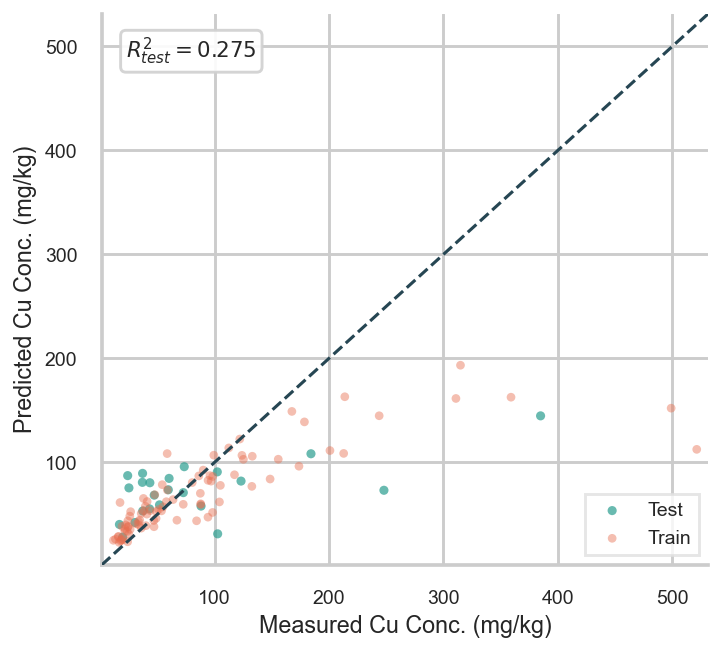

In [11]:

scatter_comparison_train_test_plot(y_pred_Cu,
                                  y_test_Cu,
                                  y_train_pred_Cu,
                                  y_train_Cu,
                                  x_label='Measured Cu Conc. (mg/kg)',
                                  y_label='Predicted Cu Conc. (mg/kg)',
                                  file_name='Cu_pred_vs_true_rfr.png')

In [12]:
# Wrap full pipeline predict (returns predictions in original Cu space)
np.random.seed(42)

explainer_Cu   = shap.KernelExplainer(rfr_Cu.predict, X_train)
shap_values_Cu = explainer_Cu.shap_values(X_test)

# Feature names
feature_names = X_test.columns.tolist()

shap_results_Cu = {}

# Store results
shap_results_Cu[targets[0]] = {
    'explainer': explainer_Cu,
    'shap_values': shap_values_Cu,
    'model': rfr_Cu
}

# Calculate mean absolute SHAP values for feature importance
shap_importance_Cu = pd.DataFrame({
    'Feature': feature_names,
    'Mean_|SHAP|': np.abs(shap_values_Cu).mean(axis=0)
}).sort_values('Mean_|SHAP|', ascending=False)

# Add percentage contribution column
shap_importance_Cu["Contribution (%)"] = (
    shap_importance_Cu["Mean_|SHAP|"] / shap_importance_Cu["Mean_|SHAP|"].sum() * 100
).round(2)

shap_importance_Cu['Cumulative (%)'] = shap_importance_Cu["Contribution (%)"].cumsum()

safe_name = targets[0].replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')
importance_Cu_path = os.path.join(output_path, safe_name)
print(f"\n  Important Features for {targets[0]} (by Mean |SHAP|):")
print(shap_importance_Cu.to_string(index=False))

shap_importance_Cu.to_csv(f'{importance_Cu_path}_rfr.csv', index=False)

100%|██████████████████████████████████████████████████████████████████████████| 23/23 [00:01<00:00, 13.10it/s]


  Important Features for Cu (mg/kg) (by Mean |SHAP|):
           Feature  Mean_|SHAP|  Contribution (%)  Cumulative (%)
  Dist_Tailing (m)    10.642260             19.86           19.86
          Silt (%)     9.419562             17.58           37.44
     Elevation (m)     5.210690              9.73           47.17
          Clay (%)     5.208148              9.72           56.89
        aspect_sin     4.278702              7.99           64.88
Dist_Near_Road (m)     4.190947              7.82           72.70
        SOM (g/kg)     3.982394              7.43           80.13
        TDS (mg/L)     3.192215              5.96           86.09
                pH     2.831491              5.28           91.37
         Slope (%)     2.176196              4.06           95.43
              NDVI     2.106659              3.93           99.36
        aspect_cos     0.337549              0.63           99.99
          Land Use     0.000000              0.00           99.99


# PREDICTION of Zn CONCENTRATIONS

In [13]:
# Load the Random Forest Model
rfr_model_Zn = RandomForestRegressor(n_estimators=52,
                                  max_features='sqrt',
                                  max_depth=6,
                                  min_samples_split=2,
                                  min_samples_leaf=4,
                                  bootstrap=True,
                                 random_state=42,
                                 n_jobs=-1)
# Load the model & Define the pipeline
rfr_pipeline_Zn = Pipeline([
    ('rfr', rfr_model_Zn)
])
# Load 
rfr_Zn = TransformedTargetRegressor(
    regressor=rfr_pipeline_Zn,
    func=np.log10,
    inverse_func=lambda x: 10**x
)

# Fit the model
rfr_Zn.fit(X_train, y_train_Zn)

# Cross Validation 5 k-folds
scores = []

for metric in scoring:
    score = cross_val_score(
        rfr_Zn, X_train, y_train_Zn, cv=5, scoring=scoring[metric]
    ).mean()
    scores.append(score)
    
# Predicting on the training set
y_train_pred_Zn = rfr_Zn.predict(X_train)

r2_train = r2_score(y_train_Zn, y_train_pred_Zn)
mae_train = mean_absolute_error(y_train_Zn, y_train_pred_Zn)
rmse_train = np.sqrt(mean_squared_error(y_train_Zn, y_train_pred_Zn))

print('#' * 40)
print('-' *10,'Validation Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {scores[0]:.4f}')
print(f'MAE: {-scores[1]:.4f}')
print(f'RMSE: {-scores[2]:.4f}')
print('')
print('#' * 40)
print('-' *10,'Training Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2_train:.4f}')
print(f'MAE: {mae_train:.4f}')
print(f'RMSE: {rmse_train:.4f}')

########################################
---------- Validation Set Scores ----------
########################################
R² Score: 0.0318
MAE: 9.7873
RMSE: 15.5488

########################################
---------- Training Set Scores ----------
########################################
R² Score: 0.3694
MAE: 7.0866
RMSE: 13.9807


In [14]:
# Predict on the test set
y_pred_Zn = rfr_Zn.predict(X_test)

r2 = r2_score(y_test_Zn, y_pred_Zn)
mae = mean_absolute_error(y_test_Zn, y_pred_Zn)
rmse = np.sqrt(mean_squared_error(y_test_Zn, y_pred_Zn))

# Predicting on the training set
y_train_pred_Zn = rfr_Zn.predict(X_train)

r2_train = r2_score(y_train_Zn, y_train_pred_Zn)
mae_train = mean_absolute_error(y_train_Zn, y_train_pred_Zn)
rmse_train = np.sqrt(mean_squared_error(y_train_Zn, y_train_pred_Zn))

print('#' * 40)
print('-' *10,'Test Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print('')
print('#' * 40)
print('-' *10,'Training Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2_train:.4f}')
print(f'MAE: {mae_train:.4f}')
print(f'RMSE: {rmse_train:.4f}')

########################################
---------- Test Set Scores ----------
########################################
R² Score: 0.0889
MAE: 7.8269
RMSE: 10.8489

########################################
---------- Training Set Scores ----------
########################################
R² Score: 0.3694
MAE: 7.0866
RMSE: 13.9807


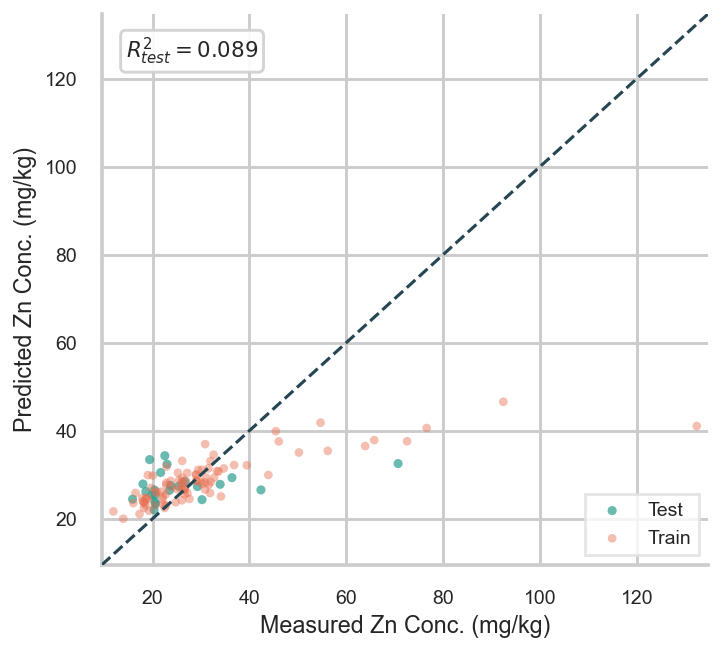

In [15]:
# Plot the scatter plot Predicted vs True Zn Conc.
scatter_comparison_train_test_plot(y_pred_Zn,
                                  y_test_Zn,
                                  y_train_pred_Zn,
                                  y_train_Zn,
                                  x_label='Measured Zn Conc. (mg/kg)',
                                  y_label='Predicted Zn Conc. (mg/kg)',
                                  file_name='Zn_pred_vs_true_rfr.png')

In [16]:
# Wrap full pipeline predict (returns predictions in original Zn space)
np.random.seed(42)

explainer_Zn   = shap.KernelExplainer(rfr_Zn.predict, X_train)
shap_values_Zn = explainer_Zn.shap_values(X_test)

# Feature names
feature_names = X_test.columns.tolist()

shap_results_Zn = {}

# Store results
shap_results_Zn[targets[1]] = {
    'explainer': explainer_Zn,
    'shap_values': shap_values_Zn,
    'model': rfr_Zn
}

# Calculate mean absolute SHAP values for feature importance
shap_importance_Zn = pd.DataFrame({
    'Feature': feature_names,
    'Mean_|SHAP|': np.abs(shap_values_Zn).mean(axis=0)
}).sort_values('Mean_|SHAP|', ascending=False)

# Add percentage contribution column
shap_importance_Zn["Contribution (%)"] = (
    shap_importance_Zn["Mean_|SHAP|"] / shap_importance_Zn["Mean_|SHAP|"].sum() * 100
).round(2)

shap_importance_Zn['Cumulative (%)'] = shap_importance_Zn["Contribution (%)"].cumsum()

safe_name = targets[1].replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')
importance_Zn_path = os.path.join(output_path, safe_name)
print(f"\n  Important Features for {targets[1]} (by Mean |SHAP|):")
print(shap_importance_Zn.to_string(index=False))

shap_importance_Zn.to_csv(f'{importance_Zn_path}_rfr.csv', index=False)

100%|██████████████████████████████████████████████████████████████████████████| 23/23 [00:01<00:00, 15.30it/s]


  Important Features for Zn (mg/kg) (by Mean |SHAP|):
           Feature  Mean_|SHAP|  Contribution (%)  Cumulative (%)
        SOM (g/kg)     1.544981             24.01           24.01
        TDS (mg/L)     1.040923             16.18           40.19
          Clay (%)     0.962919             14.96           55.15
        aspect_sin     0.727644             11.31           66.46
  Dist_Tailing (m)     0.398088              6.19           72.65
Dist_Near_Road (m)     0.378998              5.89           78.54
          Silt (%)     0.346573              5.39           83.93
              NDVI     0.273210              4.25           88.18
        aspect_cos     0.247958              3.85           92.03
     Elevation (m)     0.186167              2.89           94.92
         Slope (%)     0.111887              1.74           96.66
                pH     0.108947              1.69           98.35
          Land Use     0.106223              1.65          100.00


# PREDICTION OF Pb CONCENTRATIONS

In [17]:
#Load the Random Forest Model
rfr_model_Pb = RandomForestRegressor(n_estimators=74,
                                  max_features=0.1,
                                  max_depth=5,
                                  min_samples_split=4,
                                  min_samples_leaf=1,
                                 random_state=42,
                                 n_jobs=-1)
# Load the model & Define the pipeline
rfr_pipeline_Pb = Pipeline([
    ('rfr', rfr_model_Pb)
])
# Load 
rfr_Pb = TransformedTargetRegressor(
    regressor=rfr_pipeline_Pb,
    func=np.log10,
    inverse_func=lambda x: 10**x
)

# Fit the model
rfr_Pb.fit(X_train, y_train_Pb)

# Cross Validation 5 k-folds
scores = []

for metric in scoring:
    score = cross_val_score(
        rfr_Pb, X_train, y_train_Pb, cv=5, scoring=scoring[metric]
    ).mean()
    scores.append(score)
    
# Predicting on the training set
y_train_pred_Pb = rfr_Pb.predict(X_train)

r2_train = r2_score(y_train_Pb, y_train_pred_Pb)
mae_train = mean_absolute_error(y_train_Pb, y_train_pred_Pb)
rmse_train = np.sqrt(mean_squared_error(y_train_Pb, y_train_pred_Pb))

print('#' * 40)
print('-' *10,'Validation Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {scores[0]:.4f}')
print(f'MAE: {-scores[1]:.4f}')
print(f'RMSE: {-scores[2]:.4f}')
print('')
print('#' * 40)
print('-' *10,'Training Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2_train:.4f}')
print(f'MAE: {mae_train:.4f}')
print(f'RMSE: {rmse_train:.4f}')

########################################
---------- Validation Set Scores ----------
########################################
R² Score: 0.0510
MAE: 4.4784
RMSE: 8.2826

########################################
---------- Training Set Scores ----------
########################################
R² Score: 0.4669
MAE: 3.1392
RMSE: 6.9640


In [18]:
# Predict on the test set
y_pred_Pb = rfr_Pb.predict(X_test)

r2 = r2_score(y_test_Pb, y_pred_Pb)
mae = mean_absolute_error(y_test_Pb, y_pred_Pb)
rmse = np.sqrt(mean_squared_error(y_test_Pb, y_pred_Pb))

# Predicting on the training set
y_train_pred_Pb = rfr_Pb.predict(X_train)

r2_train = r2_score(y_train_Pb, y_train_pred_Pb)
mae_train = mean_absolute_error(y_train_Pb, y_train_pred_Pb)
rmse_train = np.sqrt(mean_squared_error(y_train_Pb, y_train_pred_Pb))

print('#' * 40)
print('-' *10,'Test Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print('')
print('#' * 40)
print('-' *10,'Training Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2_train:.4f}')
print(f'MAE: {mae_train:.4f}')
print(f'RMSE: {rmse_train:.4f}')

########################################
---------- Test Set Scores ----------
########################################
R² Score: 0.1161
MAE: 3.7149
RMSE: 10.1835

########################################
---------- Training Set Scores ----------
########################################
R² Score: 0.4669
MAE: 3.1392
RMSE: 6.9640


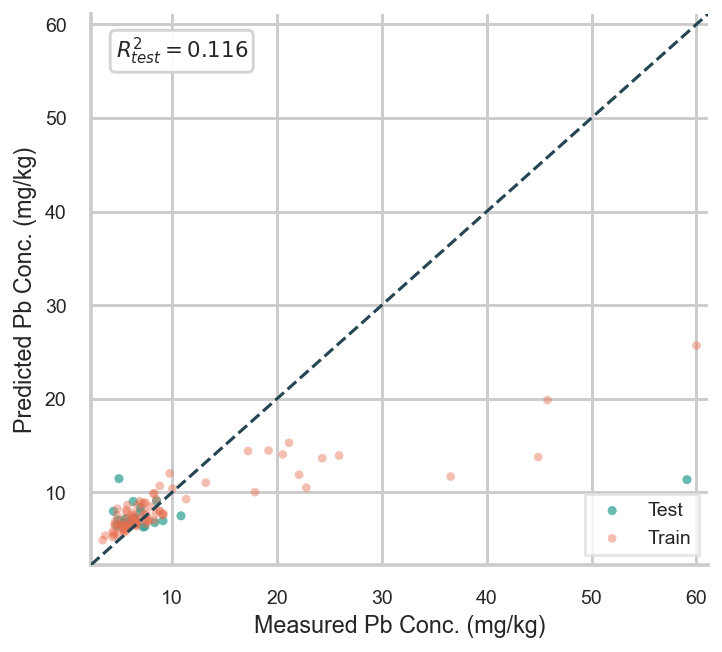

In [19]:
# Plot the scatter plot Predicted vs True Pb Conc.
scatter_comparison_train_test_plot(y_pred_Pb,
                                  y_test_Pb,
                                  y_train_pred_Pb,
                                  y_train_Pb,
                                  x_label='Measured Pb Conc. (mg/kg)',
                                  y_label='Predicted Pb Conc. (mg/kg)',
                                  file_name='Pb_pred_vs_true_rfr.png')

In [20]:
# Wrap full pipeline predict (returns predictions in original Pb space)
np.random.seed(42)

explainer_Pb   = shap.KernelExplainer(rfr_Pb.predict, X_train)
shap_values_Pb = explainer_Pb.shap_values(X_test)

# Feature names
feature_names = X_test.columns.tolist()

shap_results_Pb = {}

# Store results
shap_results_Pb[targets[2]] = {
    'explainer': explainer_Pb,
    'shap_values': shap_values_Pb,
    'model': rfr_Pb
}

# Calculate mean absolute SHAP values for feature importance
shap_importance_Pb = pd.DataFrame({
    'Feature': feature_names,
    'Mean_|SHAP|': np.abs(shap_values_Pb).mean(axis=0)
}).sort_values('Mean_|SHAP|', ascending=False)

# Add percentage contribution column
shap_importance_Pb["Contribution (%)"] = (
    shap_importance_Pb["Mean_|SHAP|"] / shap_importance_Pb["Mean_|SHAP|"].sum() * 100
).round(2)

shap_importance_Pb['Cumulative (%)'] = shap_importance_Pb["Contribution (%)"].cumsum()

safe_name = targets[2].replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')
importance_Pb_path = os.path.join(output_path, safe_name)
print(f"\n  Important Features for {targets[2]} (by Mean |SHAP|):")
print(shap_importance_Pb.to_string(index=False))

shap_importance_Pb.to_csv(f'{importance_Pb_path}_rfr.csv', index=False)

100%|██████████████████████████████████████████████████████████████████████████| 23/23 [00:01<00:00, 13.17it/s]


  Important Features for Pb (mg/kg) (by Mean |SHAP|):
           Feature  Mean_|SHAP|  Contribution (%)  Cumulative (%)
          Clay (%)     0.424209             16.05           16.05
  Dist_Tailing (m)     0.391443             14.81           30.86
Dist_Near_Road (m)     0.364180             13.78           44.64
          Land Use     0.319505             12.09           56.73
         Slope (%)     0.294287             11.13           67.86
        TDS (mg/L)     0.244466              9.25           77.11
        SOM (g/kg)     0.115260              4.36           81.47
        aspect_sin     0.113052              4.28           85.75
     Elevation (m)     0.107163              4.05           89.80
              NDVI     0.091484              3.46           93.26
                pH     0.078723              2.98           96.24
        aspect_cos     0.076671              2.90           99.14
          Silt (%)     0.023179              0.88          100.02


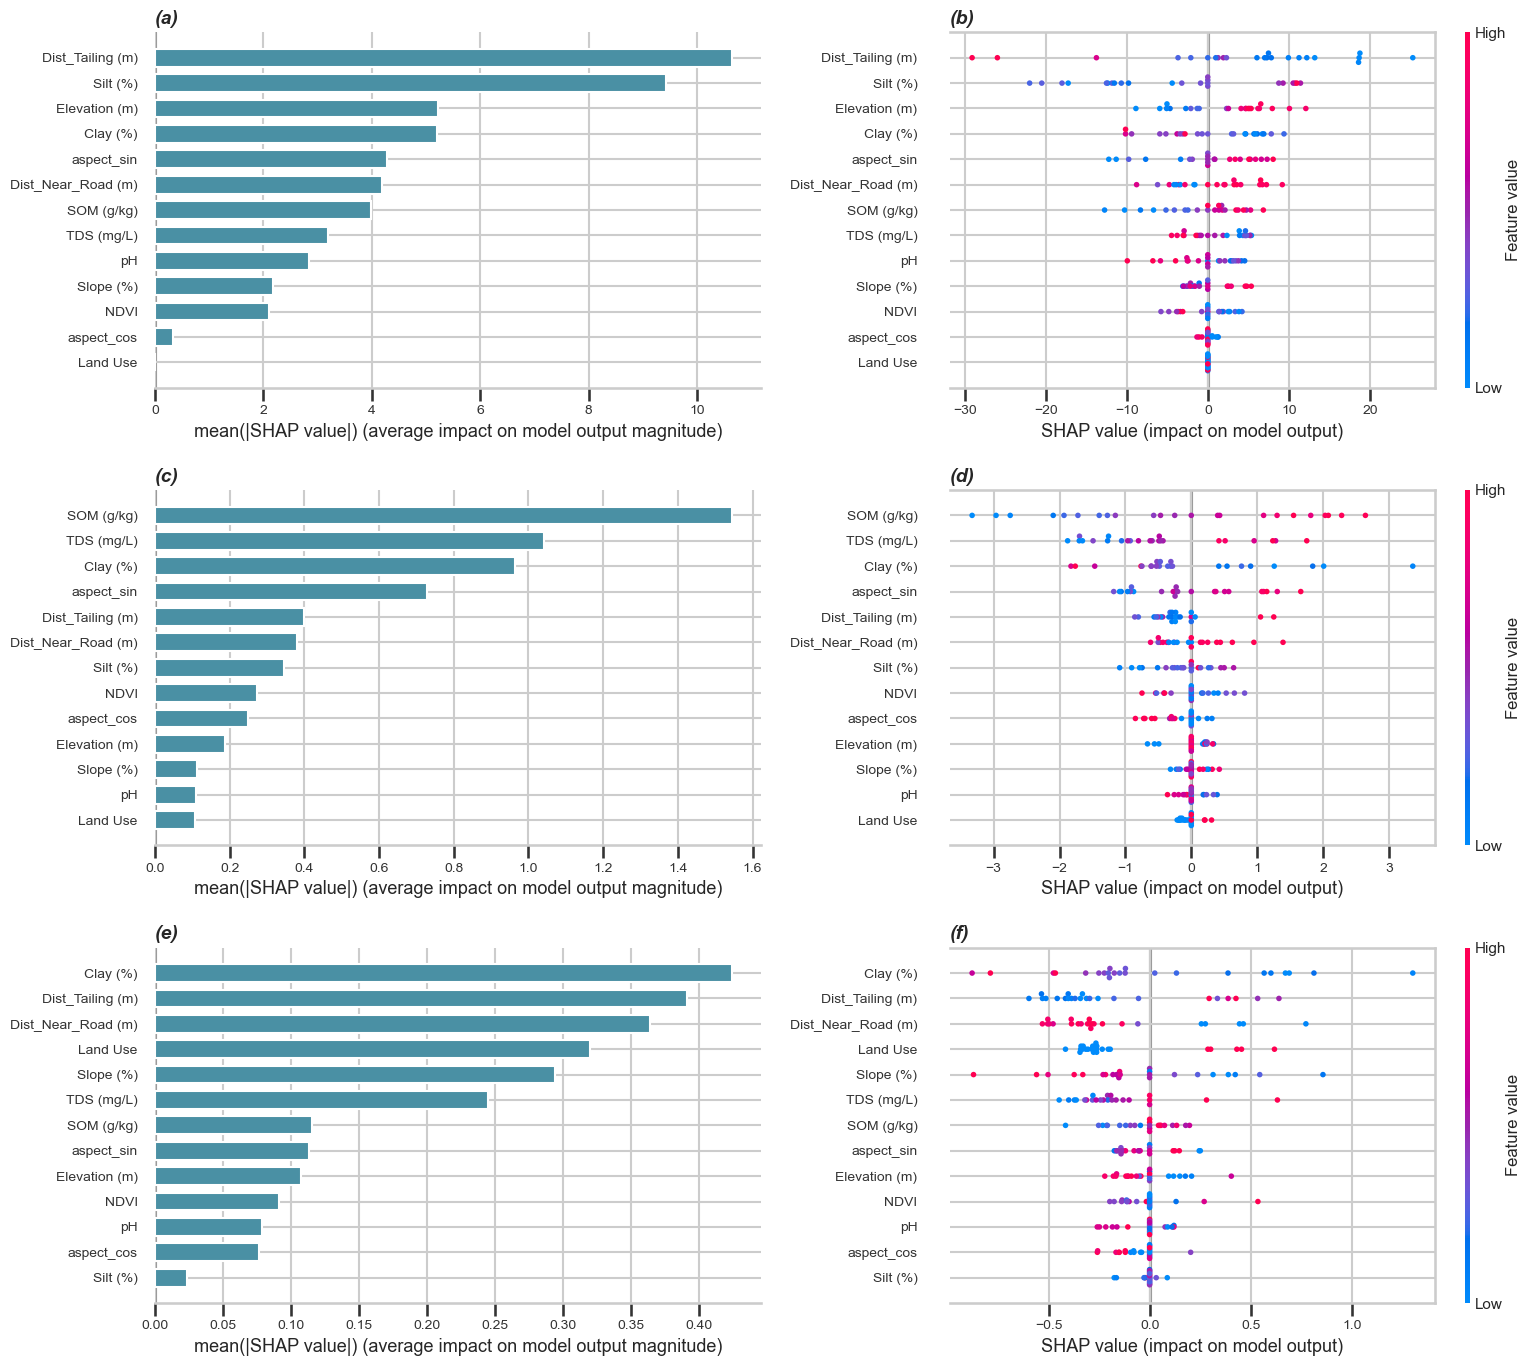

In [21]:
feature_importance_plot(X_test,
                        shap_values_Cu,
                        shap_values_Zn,
                        shap_values_Pb,
                        plot_name="Shap_Feature_Importance_Summary_Cu_Zn_Pb_RF.png")
